In [91]:
import sys

sys.path.append("../src/")
import matplotlib.pyplot as plt
import torch
from icemaker import Icemaker
from plotting_tools import plot3d, radial_distribution_function

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [107]:
dx_md = 0.5
n_md = 200
im_md = Icemaker(dx=dx_md, n=n_md)
source = "dump"
filepath = "/scratch/loh/joel/czii/stackingDisordered_20x20x20.MW_temp400.dump"

im_md.get_mdsim(filepath, startframe=10, endframe=11)

12928909it [00:01, 9165244.79it/s]
100%|█████████████████████████████████████████████| 1/1 [00:05<00:00,  5.15s/it]


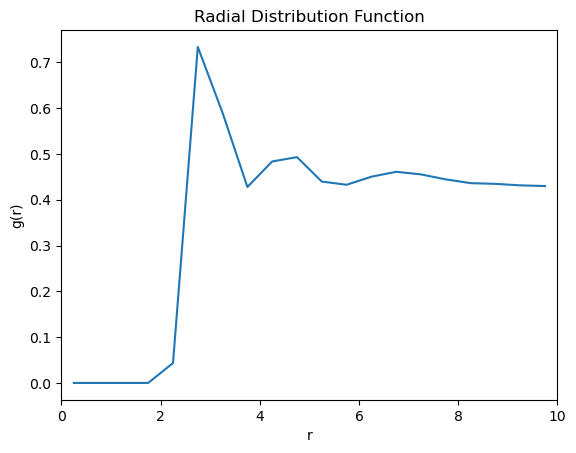

In [138]:
r_md, gr_md = radial_distribution_function(
    im_md.mdsim_ice_coordinates[0], (n_md * dx_md) ** 3, dr=0.5, r_max=10
)

In [271]:
dx = 0.5
n = 200
im = Icemaker(dx=dx_md, n=n_md, device='cuda')
source = "torch"
filepath = "../ice-data/mdsim_f_kernel_averaged_200x200x200_0.5A.pt"
im.get_mdsim_averaged_f_kernel(filepath, source=source)
im.interpolate_mdsim_f_kernel(n, dx)
im.generate_ice(dx=dx, n=n, min_distance=2)

100%|█████████████████████████████████████████████| 5/5 [00:08<00:00,  1.70s/it]


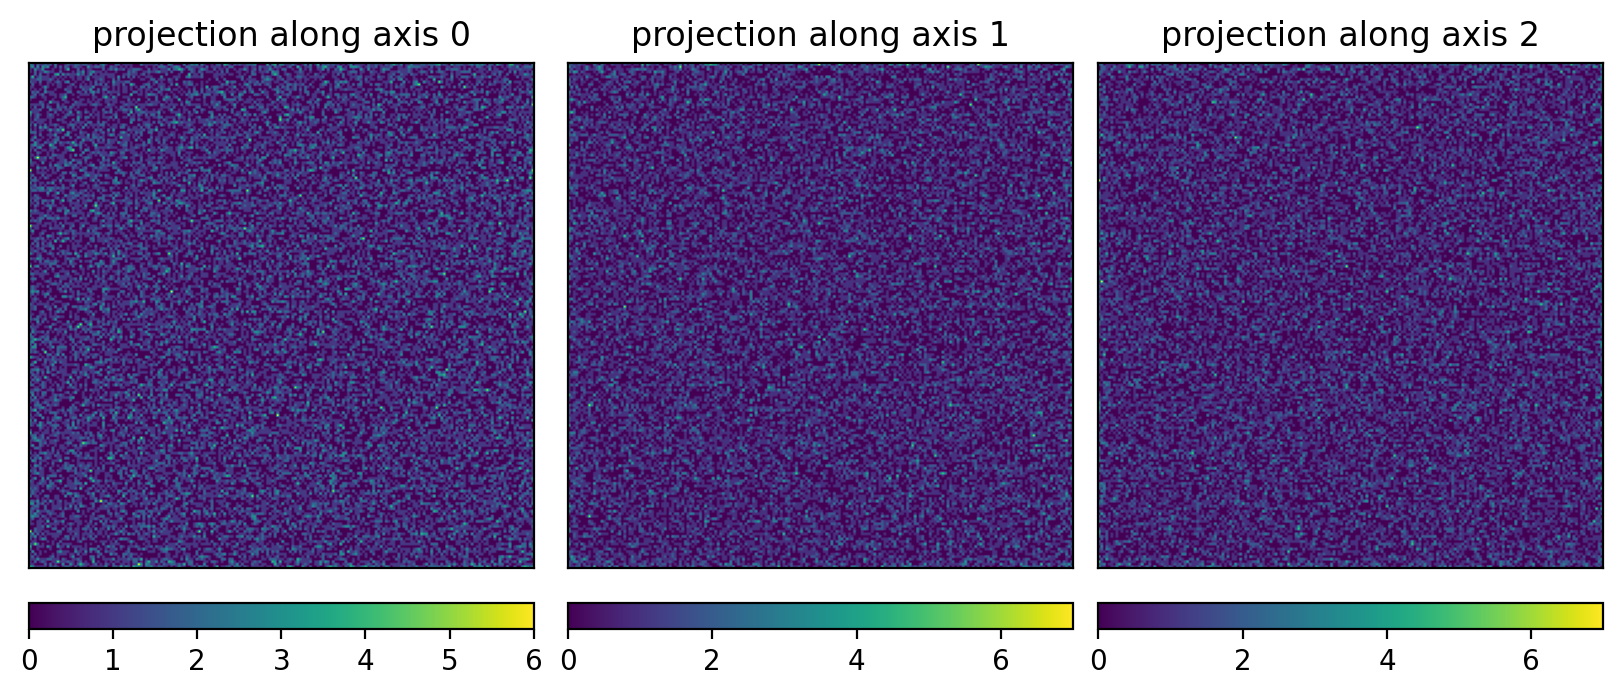

In [272]:
plot3d(im.current_ice_vol.cpu())

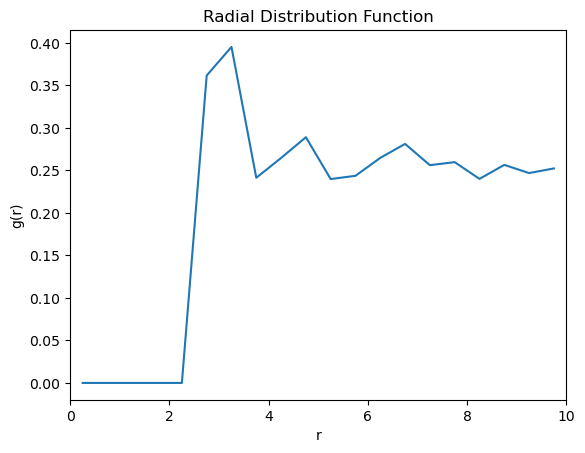

In [273]:
r, gr = radial_distribution_function(im.ice_coordinates.type(torch.float)*dx, (n * dx)**3, dr=0.5, r_max=10)

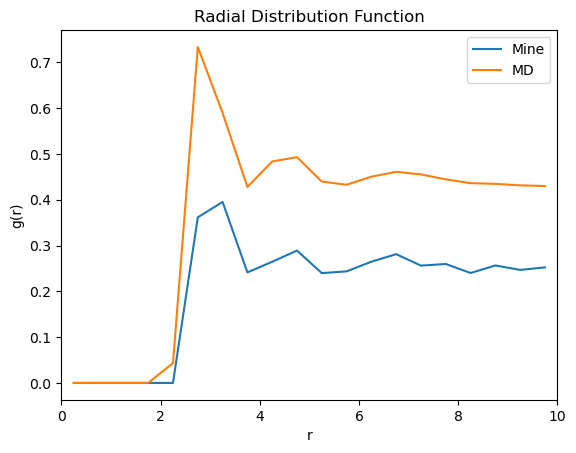

In [274]:
plt.plot(r, gr, label='Mine')
plt.plot(r_md, gr_md, label='MD')
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('Radial Distribution Function')
plt.xlim([0, 10])
plt.legend()
plt.show()